# 📊 Credit Delinquency Risk Analysis

## Exploratory Data Analysis (EDA)

Author: Sakshi Raut

Project Goal

This notebook performs an exploratory data analysis on a customer credit delinquency dataset to assess data quality, identify missing values, uncover behavioral patterns, and discover key financial risk indicators that may influence customer delinquency.

---

# 2. Objectives

The primary objectives of this analysis are:

- Understand the structure of the dataset.
- Evaluate overall data quality.
- Detect missing values and inconsistencies.
- Explore distributions of numerical and categorical variables.
- Identify potential indicators of customer delinquency.
- Generate business insights to support predictive modeling.

 Import Libraries

In [14]:
# =====================================================
# Import Required Libraries
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully.")

Libraries imported successfully.


Load Dataset

In [15]:
# =====================================================
# Load Dataset
# =====================================================

DATA_PATH = "../data/raw/Delinquency_prediction_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 3. Initial Dataset Inspection

In this section, we examine the overall structure of the dataset, including its dimensions, data types, and sample observations. This provides a high-level understanding before performing detailed exploratory analysis.

In [16]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 500
Columns : 19


Dataset Dimensions

In [17]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [18]:
df.tail()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed
499,CUST0500,25,40945.0,442.0,0.911370,1,0,36968.0,0.370422,Self-employed,0,Business,Houston,Missed,Late,Late,On-time,Late,On-time


In [19]:
df.sample(5, random_state=42)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
361,CUST0362,58,180421.0,679.0,0.971116,2,0,53553.0,0.291088,employed,15,Gold,Phoenix,Late,Missed,Late,On-time,On-time,Late
73,CUST0074,21,36447.0,448.0,0.878607,3,0,13355.0,0.187290,Self-employed,11,Business,Houston,On-time,On-time,Missed,Late,On-time,Missed
374,CUST0375,34,101900.0,648.0,0.787708,1,1,48942.0,0.314334,Unemployed,14,Standard,Houston,Missed,Missed,Missed,Missed,On-time,Missed
155,CUST0156,22,119185.0,711.0,0.943684,0,0,44454.0,0.205295,employed,11,Student,Phoenix,Late,Missed,On-time,Late,Missed,Missed
104,CUST0105,42,178165.0,383.0,0.425235,2,0,NaN,0.176706,Self-employed,15,Gold,New York,Missed,On-time,Missed,On-time,On-time,Late


Summary Statistics:

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,46.266000,16.187629,18.00,33.000000,46.500000,59.250000,74.000000
Income,461.0,108379.893709,53662.723741,15404.00,62295.000000,107658.000000,155734.000000,199943.000000
Credit_Score,498.0,577.716867,168.881211,301.00,418.250000,586.000000,727.250000,847.000000
Credit_Utilization,500.0,0.491446,0.197103,0.05,0.356486,0.485636,0.634440,1.025843
Missed_Payments,500.0,2.968000,1.946935,0.00,1.000000,3.000000,5.000000,6.000000
Delinquent_Account,500.0,0.160000,0.366973,0.00,0.000000,0.000000,0.000000,1.000000
Loan_Balance,471.0,48654.428875,29395.537273,612.00,23716.500000,45776.000000,75546.500000,99620.000000
Debt_to_Income_Ratio,500.0,0.298862,0.094521,0.10,0.233639,0.301634,0.362737,0.552956
Account_Tenure,500.0,9.740000,5.923054,0.00,5.000000,10.000000,15.000000,19.000000


In [21]:
df.describe(include="object").T

,count,unique,top,freq
Customer_ID,500,500,CUST0001,1
Employment_Status,500,6,Unemployed,93
Credit_Card_Type,500,5,Gold,118
Location,500,5,Los Angeles,107
Month_1,500,3,On-time,177
Month_2,500,3,Late,173
Month_3,500,3,Late,169
Month_4,500,3,Late,181
Month_5,500,3,Missed,187
Month_6,500,3,Late,172


# 4. Data Quality Assessment

Data quality assessment helps determine whether the dataset is reliable for analysis and predictive modeling. This includes evaluating missing values, duplicate records, variable types, and summary statistics.

In [22]:
def missing_summary(dataframe):

    missing = dataframe.isnull().sum()

    percentage = (
        missing
        / len(dataframe)
        *100
    )

    summary = pd.DataFrame({

        "Missing Values":missing,

        "Percentage":percentage.round(2)

    })

    summary=summary[summary["Missing Values"]>0]

    return summary.sort_values(
        by="Missing Values",
        ascending=False
    )

In [23]:
missing_summary(df)

,Missing Values,Percentage
Income,39,7.8
Loan_Balance,29,5.8
Credit_Score,2,0.4


Visualize Missing Values

Check for Duplicates

In [24]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


## Initial Observations

Key findings from the data quality assessment:

- The dataset contains **500 customer records** and **19 variables**.
- Missing values are limited to Income, Loan Balance, and Credit Score.
- No duplicate records were identified.
- Most numerical variables fall within expected business ranges.
- Credit Utilization slightly exceeds 100% for a small number of customers, suggesting possible over-limit credit usage.
- The target variable is imbalanced, with only 16% delinquent accounts.

# 5. Visualization Utilities

To ensure consistency across all visualizations, reusable plotting functions are defined in this section. These functions standardize the appearance of charts and reduce repetitive code throughout the analysis.

In [25]:
# =====================================================
# Distribution Plot
# =====================================================

def plot_distribution(dataframe, column):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )

    # Histogram
    sns.histplot(
        dataframe[column],
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f"{column} Distribution")
    axes[0].set_xlabel(column)

    # Boxplot
    sns.boxplot(
        x=dataframe[column],
        ax=axes[1]
    )

    axes[1].set_title(f"{column} Boxplot")

    plt.tight_layout()
    plt.show()

In [26]:
# =====================================================
# Count Plot
# =====================================================

def plot_count(dataframe, column):

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=dataframe,
        x=column,
        order=dataframe[column].value_counts().index
    )

    plt.title(f"{column} Distribution")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

In [27]:
# =====================================================
# Target Comparison Plot
# =====================================================

def compare_with_target(dataframe, feature, target):

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=dataframe,
        x=target,
        y=feature
    )

    plt.title(f"{feature} vs {target}")

    plt.tight_layout()

    plt.show()

# 6. Univariate Analysis

Univariate analysis examines each variable independently to understand its distribution, identify potential outliers, and assess overall data quality. This step provides a foundation for deeper relationship analysis in later stages.

Numerical Variables

In [28]:
numerical_features = [
    "Age",
    "Income",
    "Credit_Score",
    "Credit_Utilization",
    "Missed_Payments",
    "Loan_Balance",
    "Debt_to_Income_Ratio",
    "Account_Tenure"
]

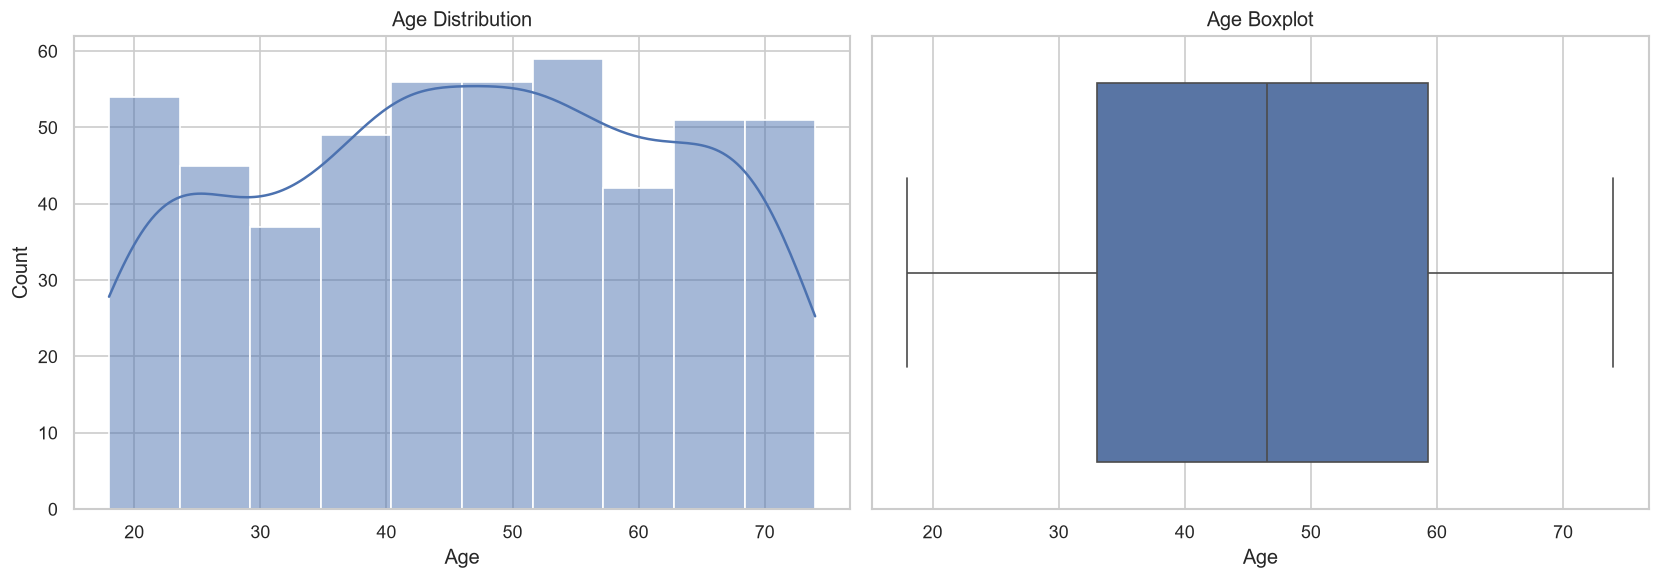

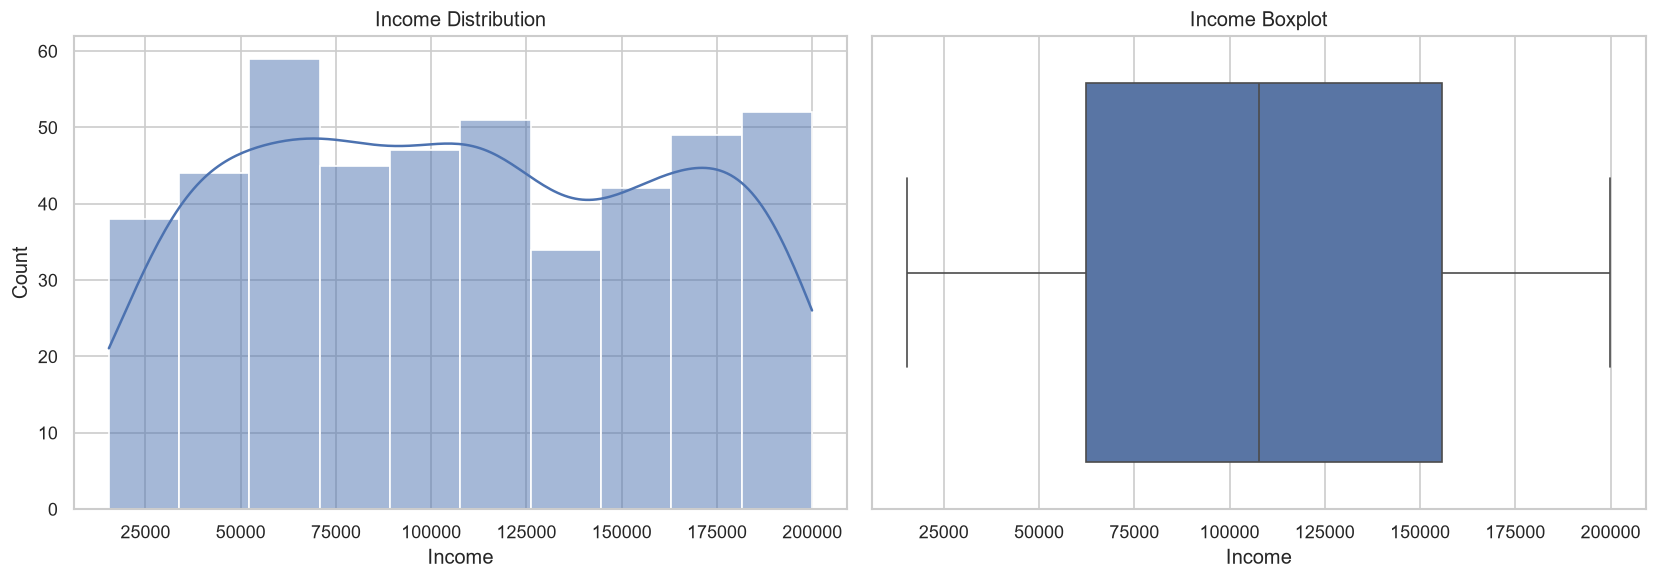

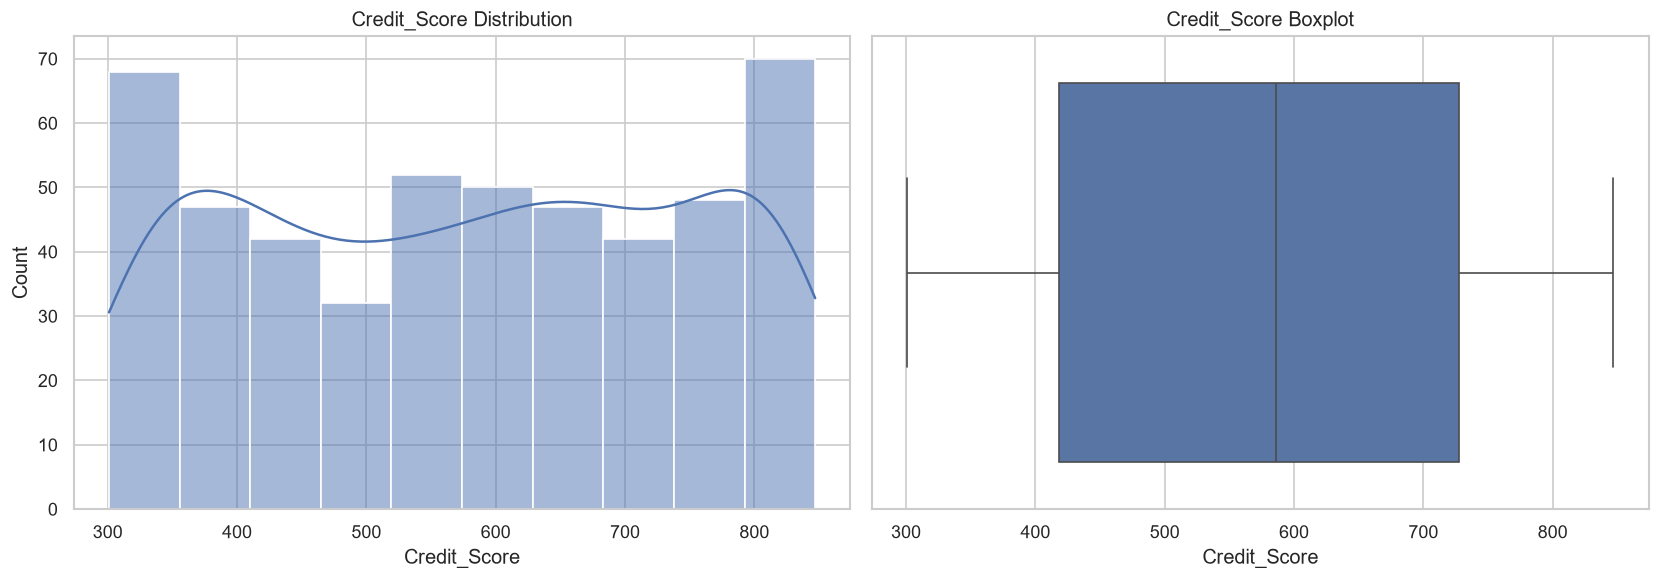

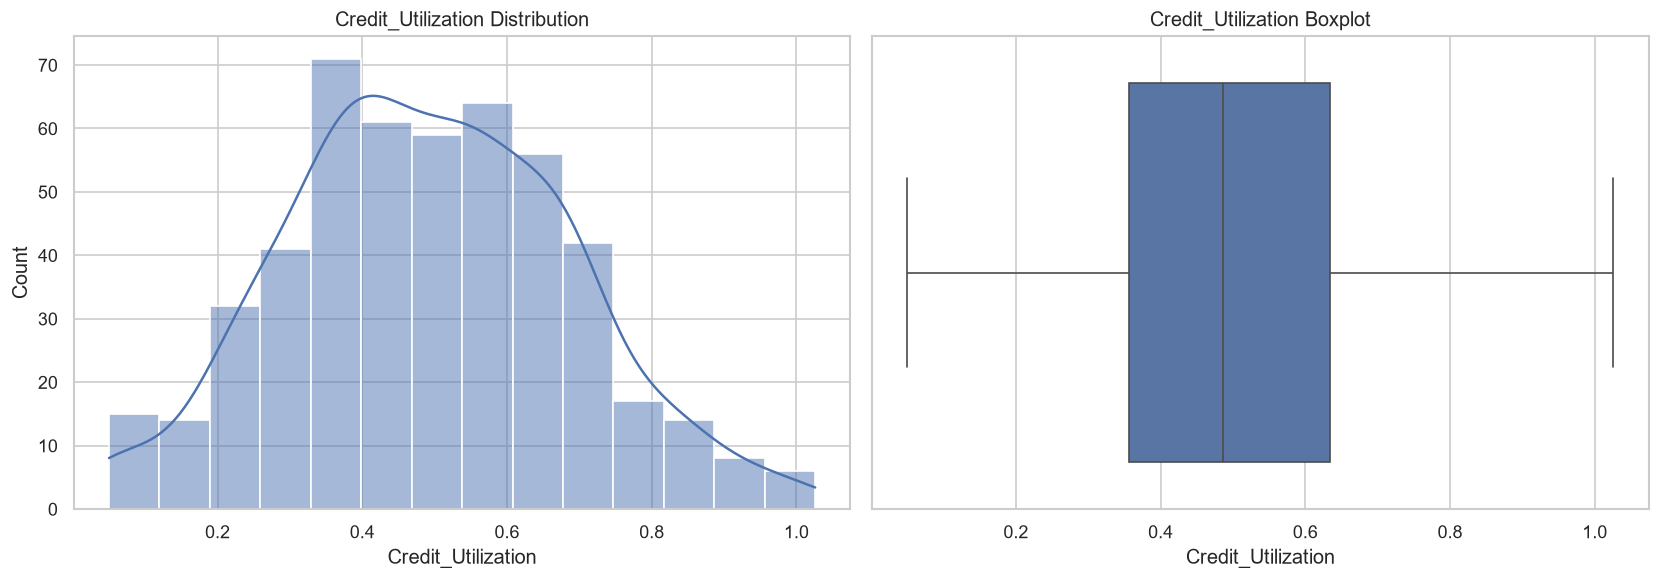

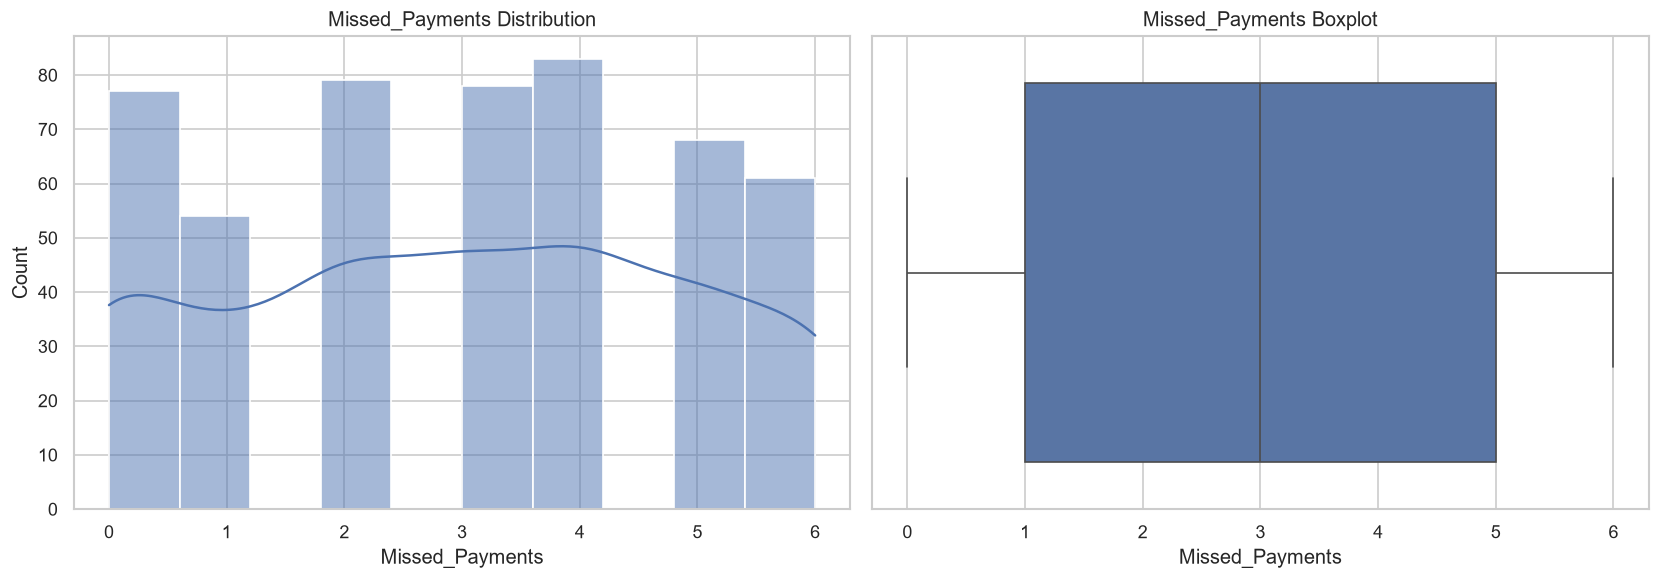

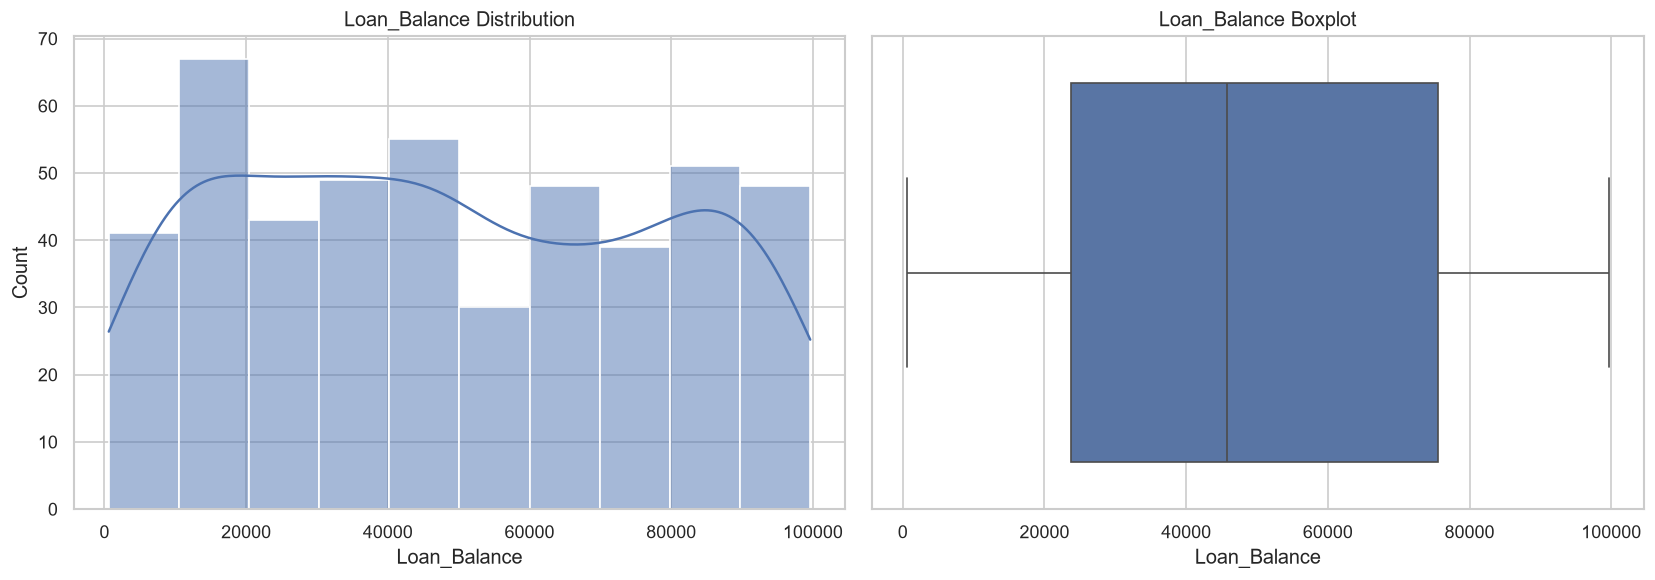

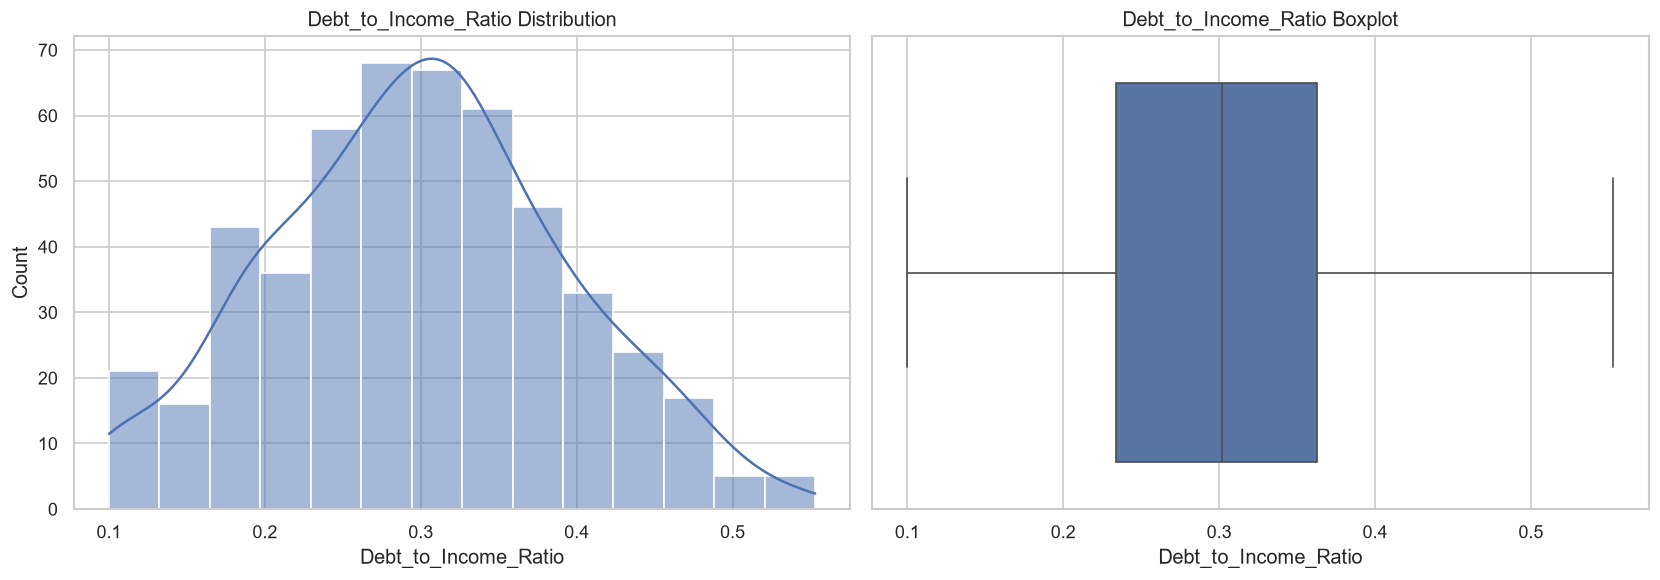

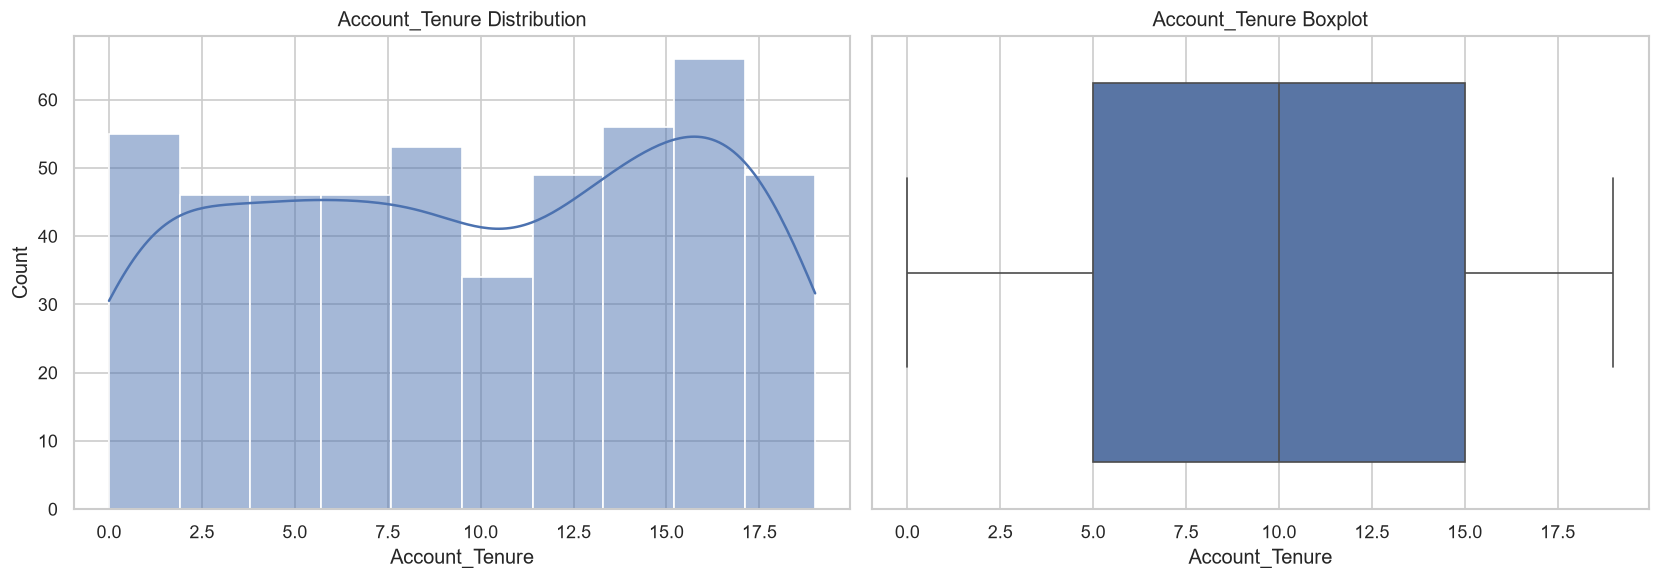

In [29]:
for column in numerical_features:
    plot_distribution(df, column)

## Categorical Variable Analysis

Categorical variables provide insights into customer segments and account characteristics. Understanding their distributions helps identify dominant customer groups and supports later comparisons with delinquency outcomes.

In [30]:
categorical_features = [
    "Employment_Status",
    "Credit_Card_Type",
    "Location"
]

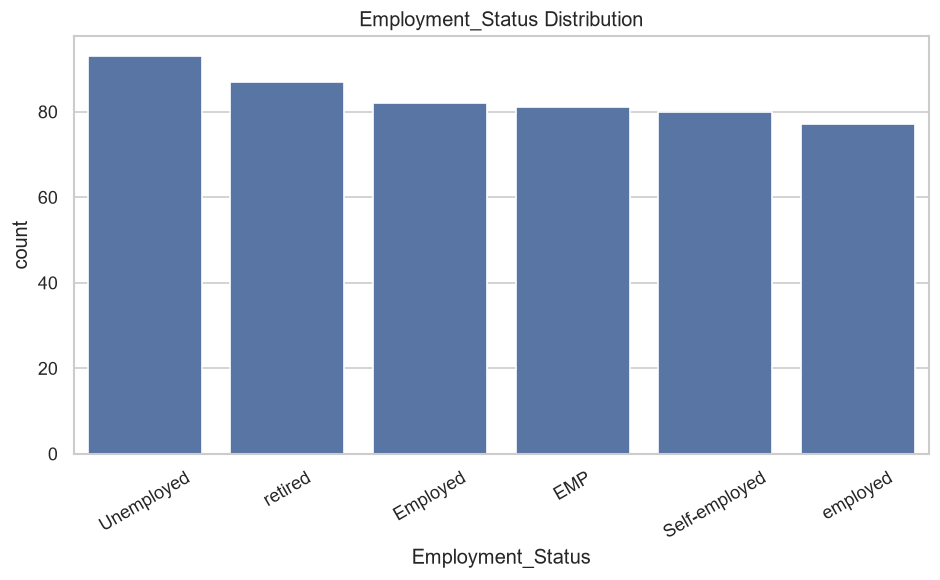

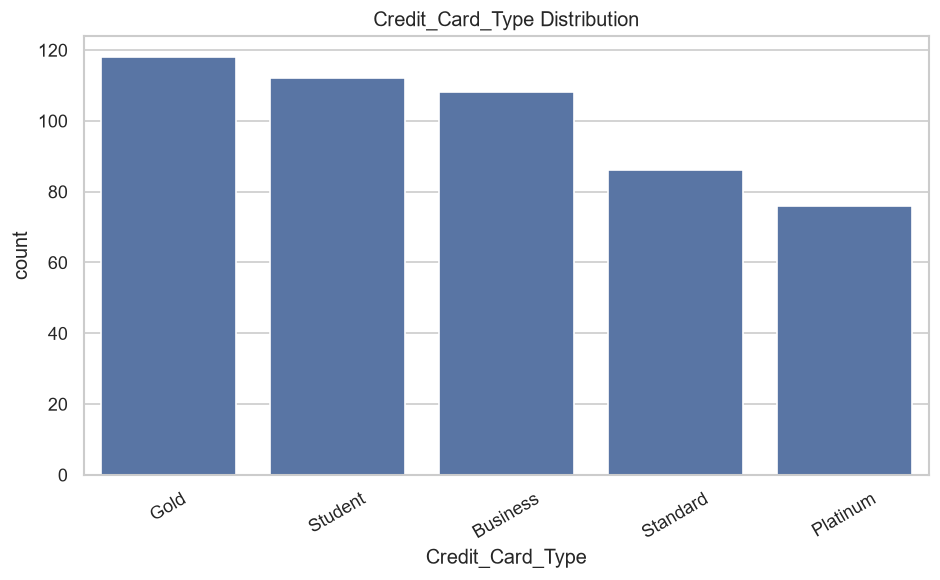

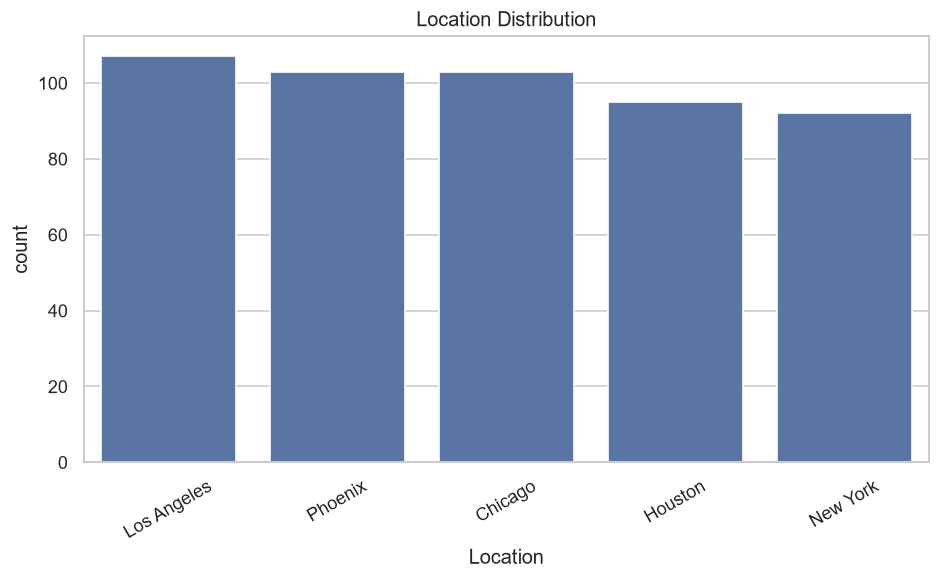

In [31]:
for column in categorical_features:
    plot_count(df, column)

# 7. Target Variable Analysis

The target variable represents whether a customer has a delinquent account. Understanding its distribution is essential before building predictive models, as class imbalance can significantly influence model performance.

Count Plot

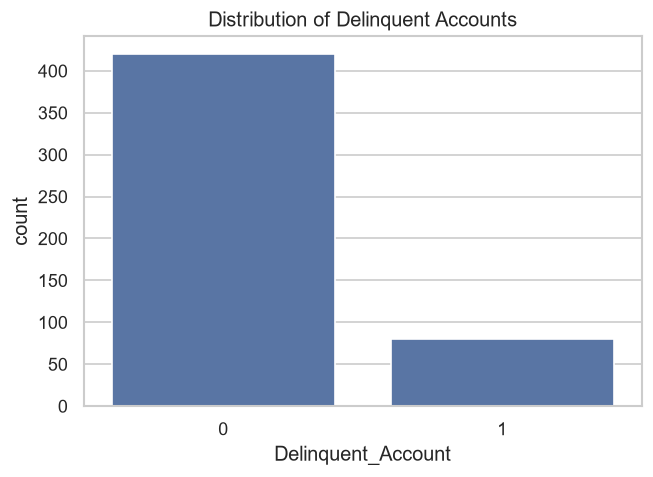

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Delinquent_Account"
)

plt.title("Distribution of Delinquent Accounts")

plt.show()

Percentage Table

In [33]:
target_distribution = (
    df["Delinquent_Account"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution

Delinquent_Account
0    84.0
1    16.0
Name: proportion, dtype: float64

In [34]:
plt.savefig(
    "../visuals/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 1200x720 with 0 Axes>

Age

### Business Interpretation

- Customer ages range from approximately **18 to 74 years**, with the distribution spread fairly evenly across adult age groups.
- The median age is around **46 years**, indicating that the customer base primarily consists of middle-aged individuals.
- No significant outliers are observed, suggesting good data quality.
- Age alone is unlikely to explain delinquency and should be analyzed alongside financial variables such as income and credit score.

Income

### Business Interpretation

- Annual income is broadly distributed across the customer base, indicating representation from multiple income segments.
- The distribution appears relatively balanced with no extreme outliers.
- Approximately **7.8%** of income values are missing and will require imputation before predictive modeling.
- Income is expected to influence repayment capacity and will later be analyzed against delinquency status.

Credit Score

### Business Interpretation

- Credit scores range from approximately **300 to 850**, covering poor to excellent credit profiles.
- The distribution appears realistic without impossible values.
- Only **two observations** contain missing values, making simple median imputation appropriate.
- Customers with lower credit scores are expected to exhibit higher delinquency risk and will be investigated further.

Credit Utilization

### Business Interpretation

- Most customers utilize between **30% and 70%** of their available credit.
- A few observations exceed **100% credit utilization**, indicating customers who have exceeded their assigned credit limits.
- Rather than treating these as errors, they may represent financially stressed customers and should be retained for further analysis.

Missed Payments

### Business Interpretation

- Missed payments range from **0 to 6**, indicating varying repayment behavior.
- Most customers have relatively few missed payments, although a meaningful proportion have multiple missed payments.
- Since payment history is often one of the strongest predictors of default, this variable is expected to play a major role in delinquency prediction.

Loan Balance

### Business Interpretation

- Outstanding loan balances vary considerably across customers, indicating different borrowing behaviors.
- The absence of extreme outliers suggests the values are within expected business ranges.
- Approximately **5.8%** of records contain missing loan balance values, which will be addressed during data cleaning.

Debt-to-Income Ratio

### Business Interpretation

- Debt-to-income ratios range between approximately **10% and 55%**, reflecting varying levels of financial obligation.
- Higher ratios may indicate greater financial stress and reduced repayment capacity.
- This variable is expected to be an important indicator of delinquency risk.

Account Tenure

### Business Interpretation

- Customer tenure ranges from new accounts to long-term customers.
- A broad distribution suggests representation from both recently acquired and established customers.
- Longer customer relationships may indicate greater financial stability, which will be explored further during bivariate analysis.

Categorical Variables

Employment Status

### Business Interpretation

- The dataset includes customers from multiple employment categories.
- No single employment category overwhelmingly dominates the dataset.
- Employment status may influence repayment capacity and will be compared against delinquency outcomes in later analysis.

Credit Card Type

### Business Interpretation

- Gold, Student, and Business cards appear to be the most common card types.
- Premium card categories represent a smaller proportion of customers.
- Card type may indirectly reflect customer income level, creditworthiness, and spending behavior.

Location

### Business Interpretation

- Customers are distributed relatively evenly across all locations.
- No significant geographical imbalance is observed.
- Regional differences in delinquency rates will be explored during bivariate analysis.

Target Variable

## Business Interpretation

The dataset contains approximately **84% non-delinquent customers** and **16% delinquent customers**, indicating a moderate class imbalance.

Although this imbalance is not severe, predictive models may become biased toward the majority class if left untreated.

Potential mitigation strategies during the modeling phase include:

- Class weighting
- SMOTE (Synthetic Minority Oversampling Technique)
- Balanced evaluation metrics such as F1-score and ROC-AUC

# 8. Bivariate Analysis

This section explores relationships between customer attributes and delinquency status to identify patterns that may serve as important predictors in future risk models.

Numerical Variables vs Delinquency

Function

In [35]:
# =====================================================
# Numerical Feature vs Target
# =====================================================

def plot_numeric_vs_target(df, feature, target='Delinquent_Account'):

    fig, axes = plt.subplots(1,2, figsize=(14,5))

    # Boxplot
    sns.boxplot(
        data=df,
        x=target,
        y=feature,
        ax=axes[0]
    )

    axes[0].set_title(f"{feature} vs {target}")

    # Violin Plot
    sns.violinplot(
        data=df,
        x=target,
        y=feature,
        ax=axes[1]
    )

    axes[1].set_title(f"{feature} Distribution by {target}")

    plt.tight_layout()
    plt.show()

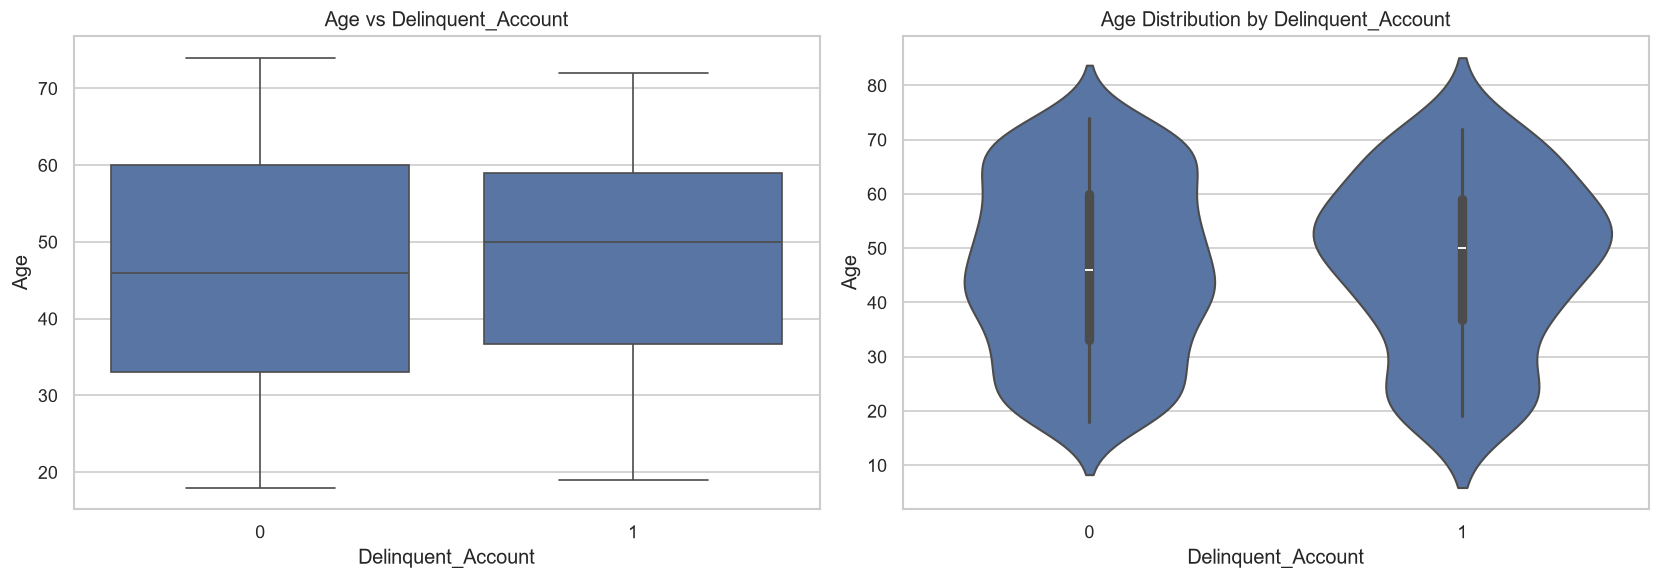

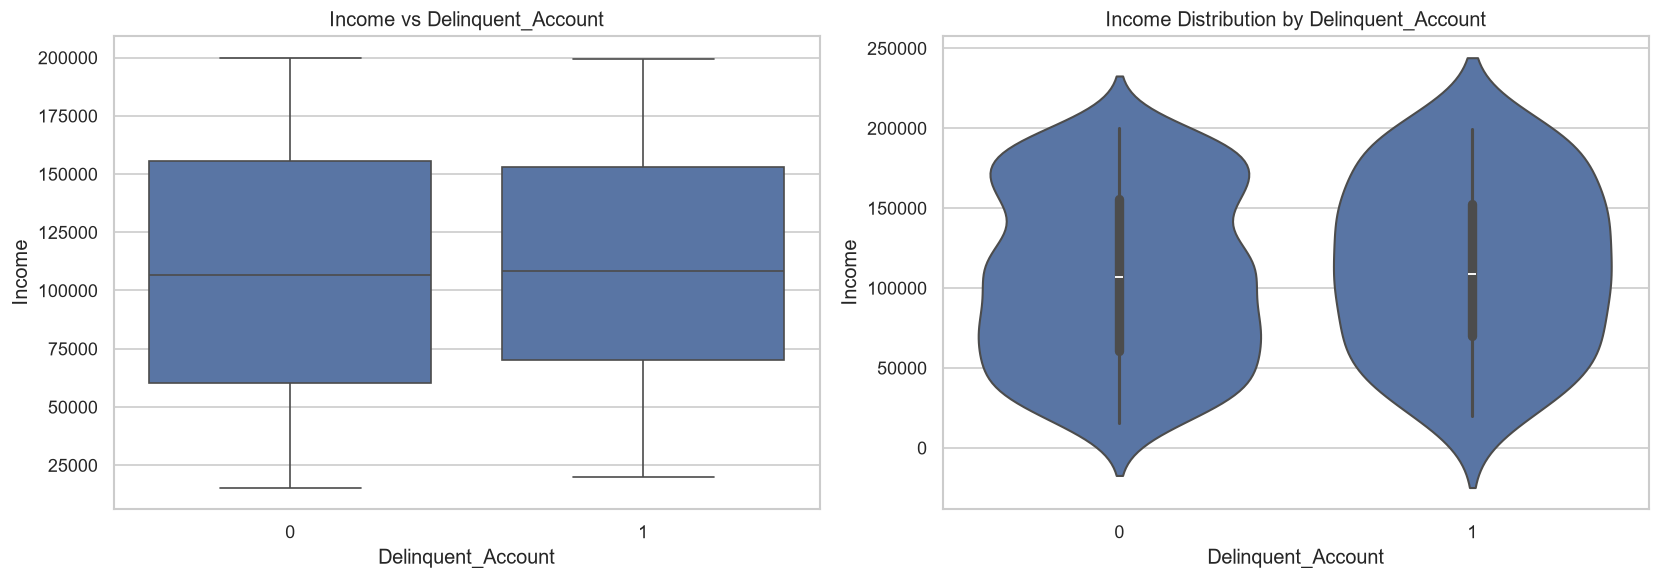

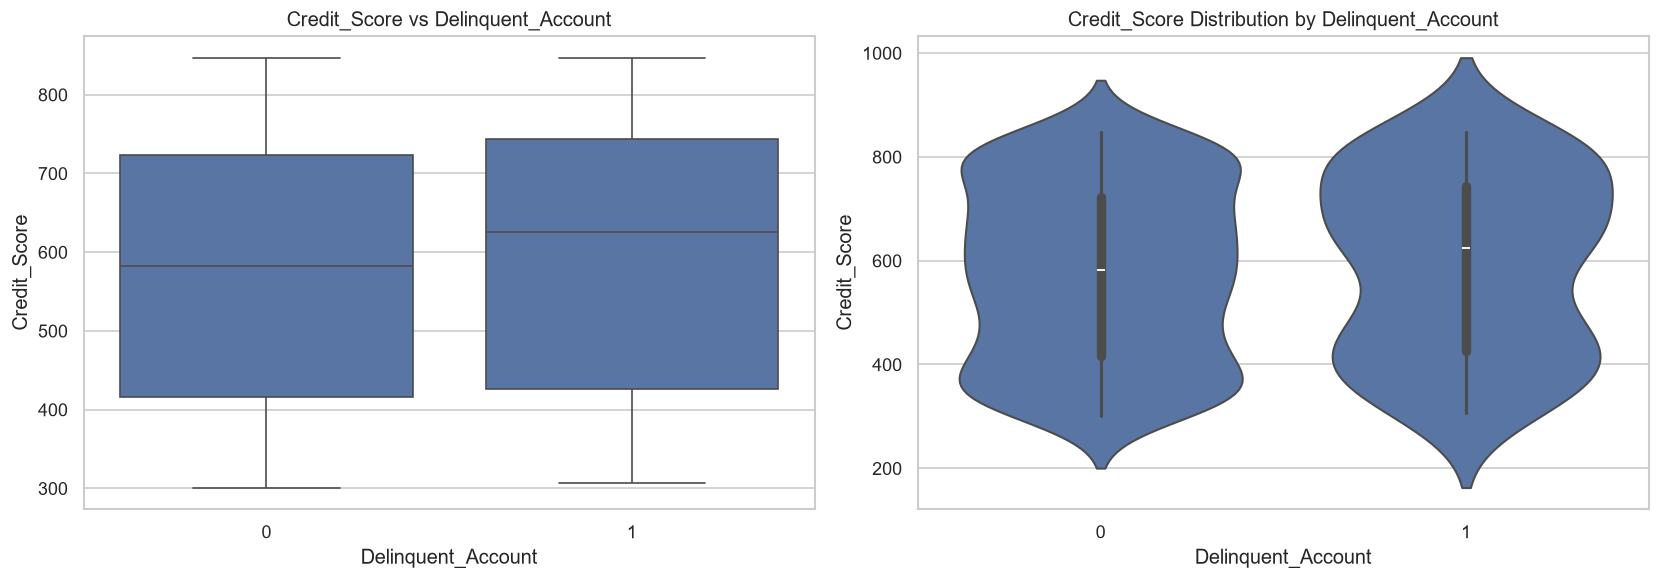

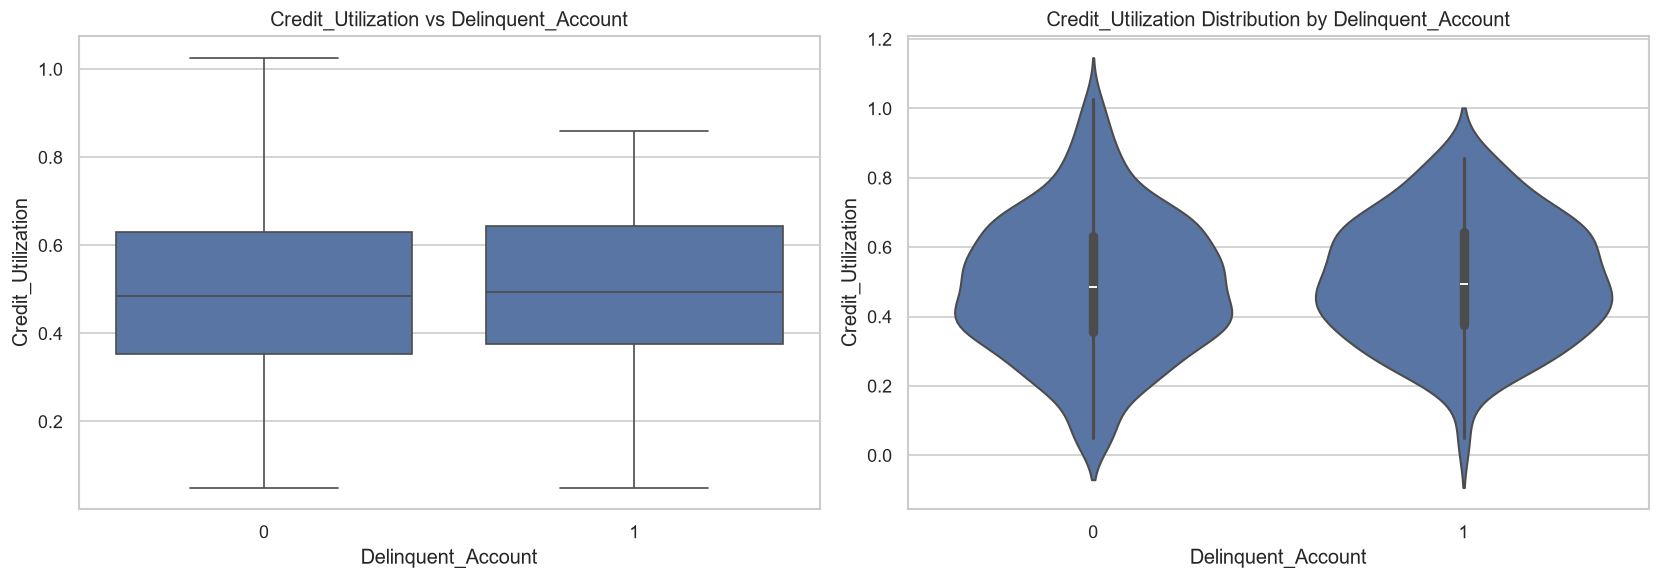

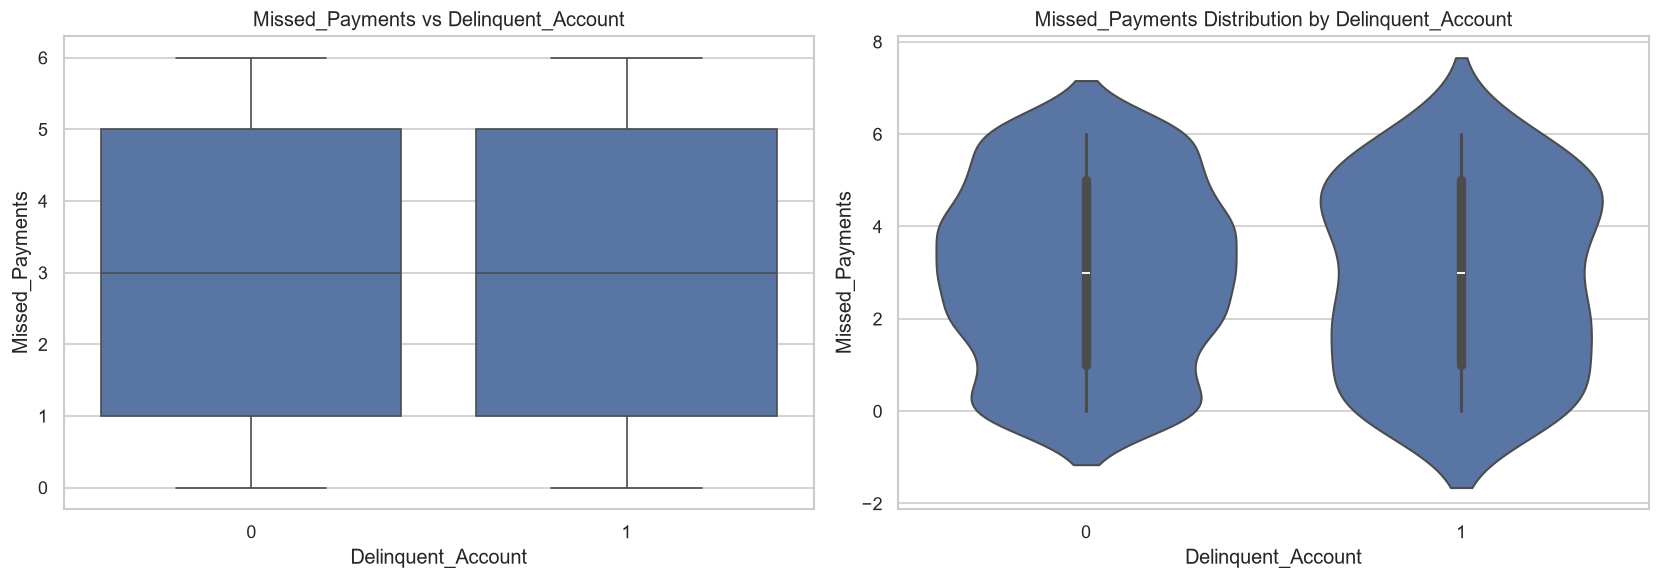

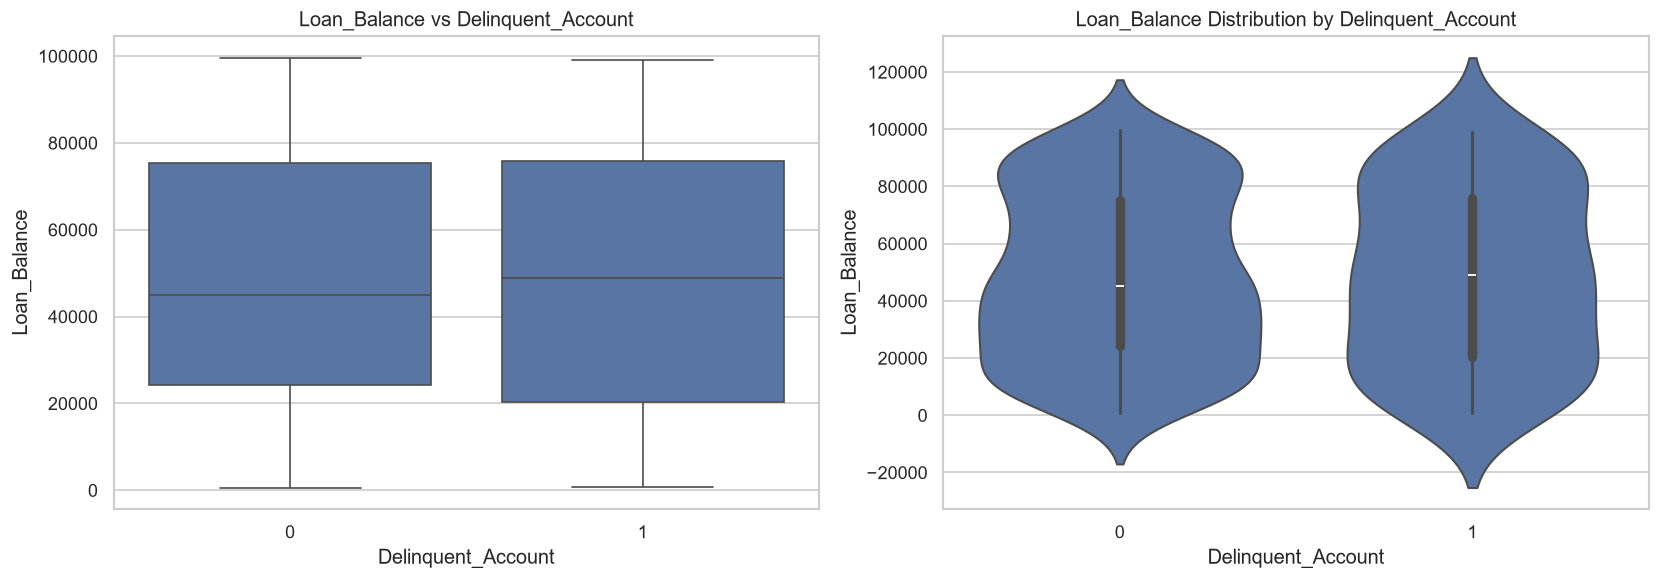

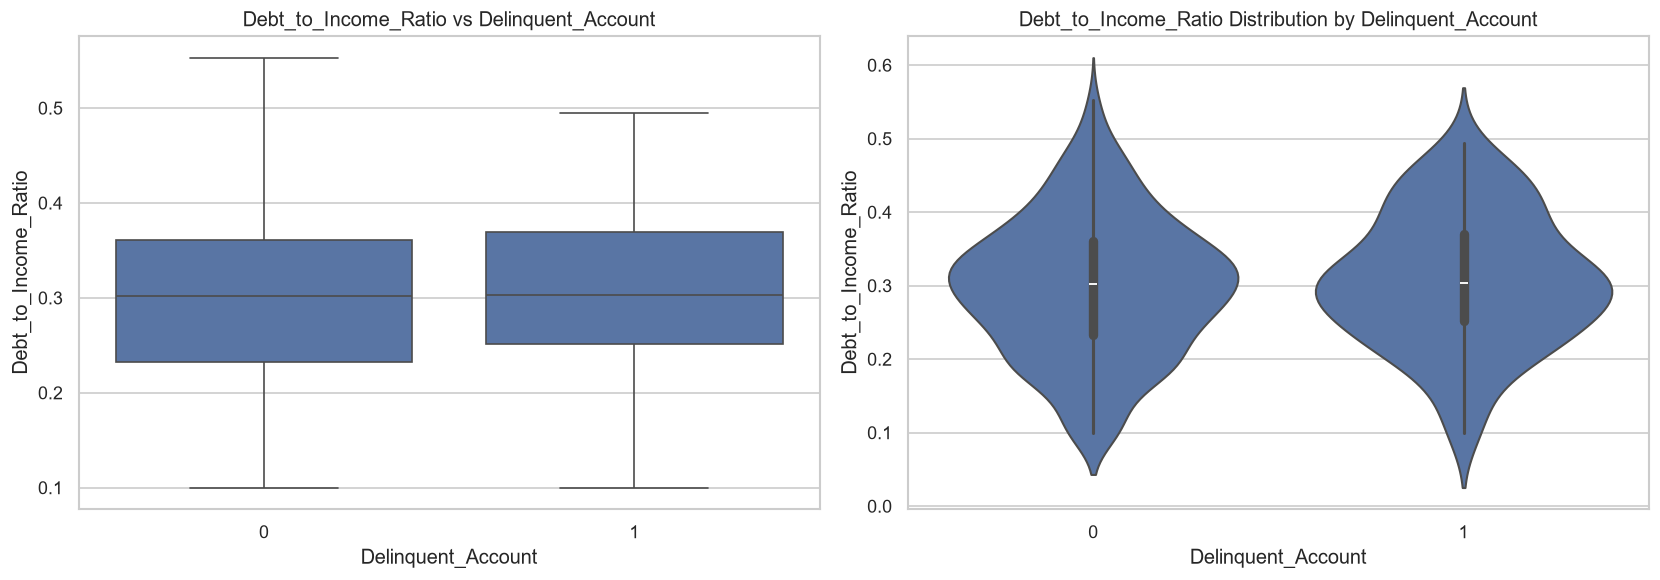

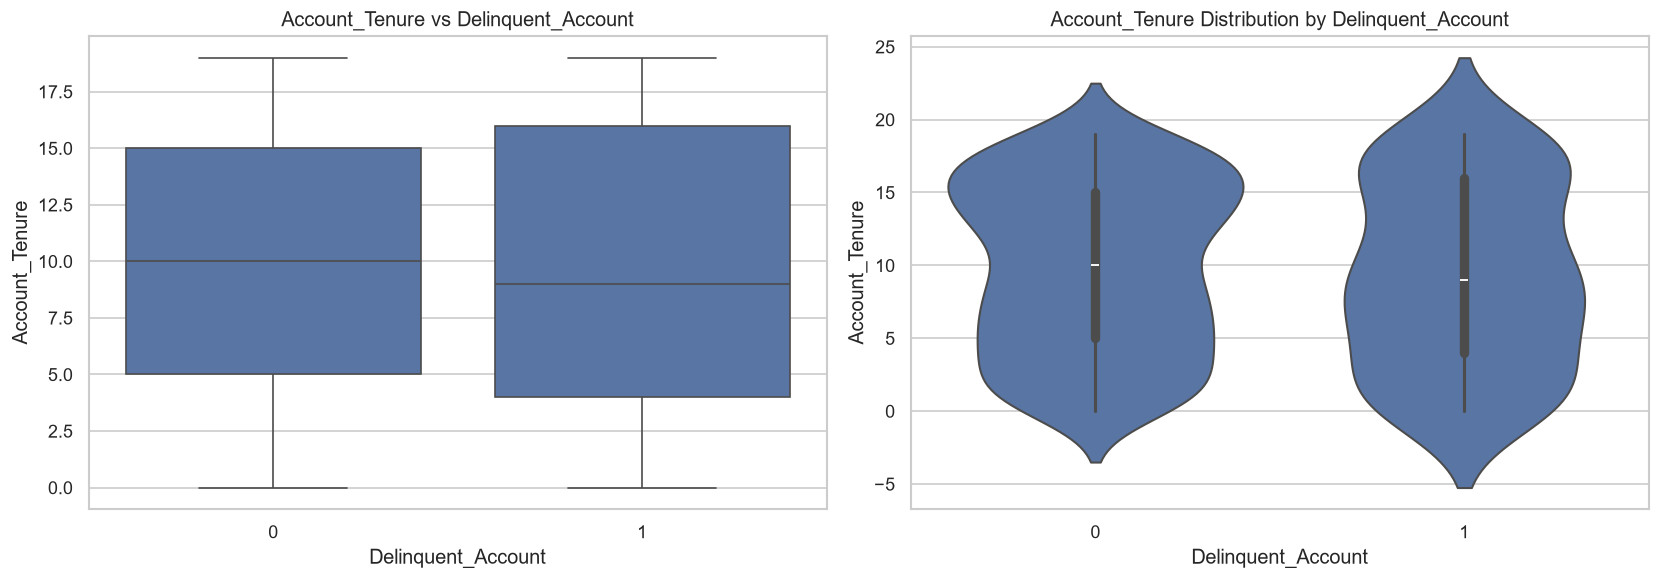

In [36]:
for feature in numerical_features:
    plot_numeric_vs_target(df, feature)

Categorical Variables vs Delinquency

In [37]:
# =====================================================
# Categorical Feature vs Target
# =====================================================

def plot_categorical_vs_target(df, feature, target='Delinquent_Account'):

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=feature,
        hue=target
    )

    plt.title(f"{feature} vs {target}")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

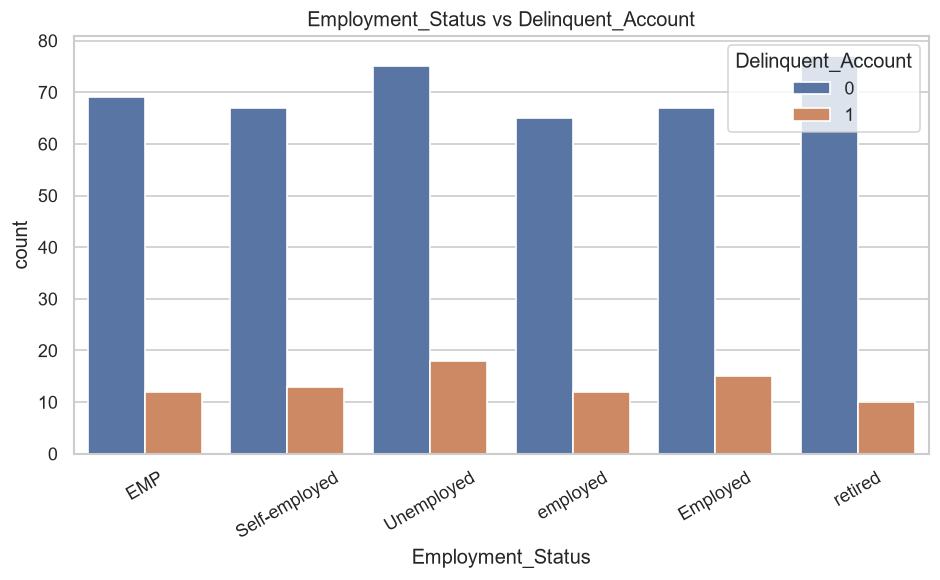

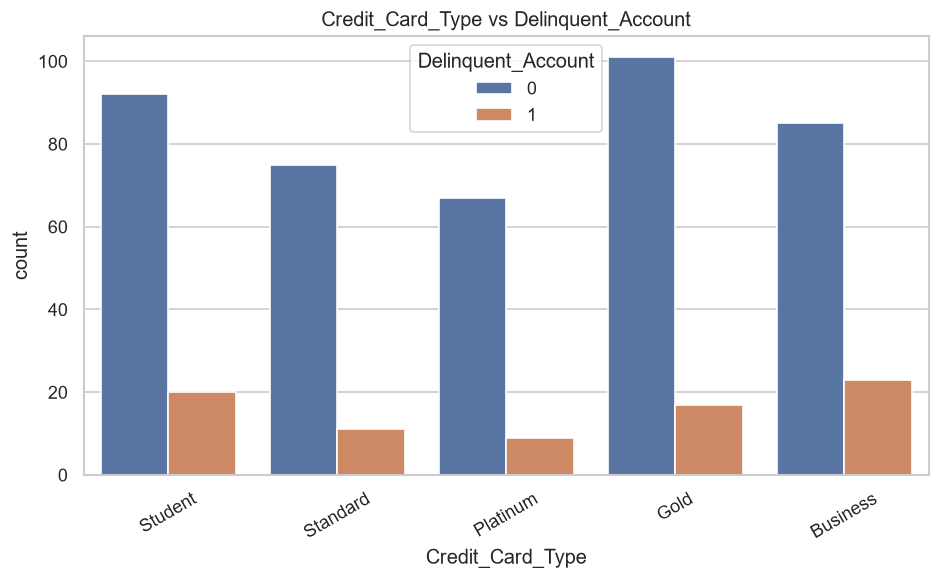

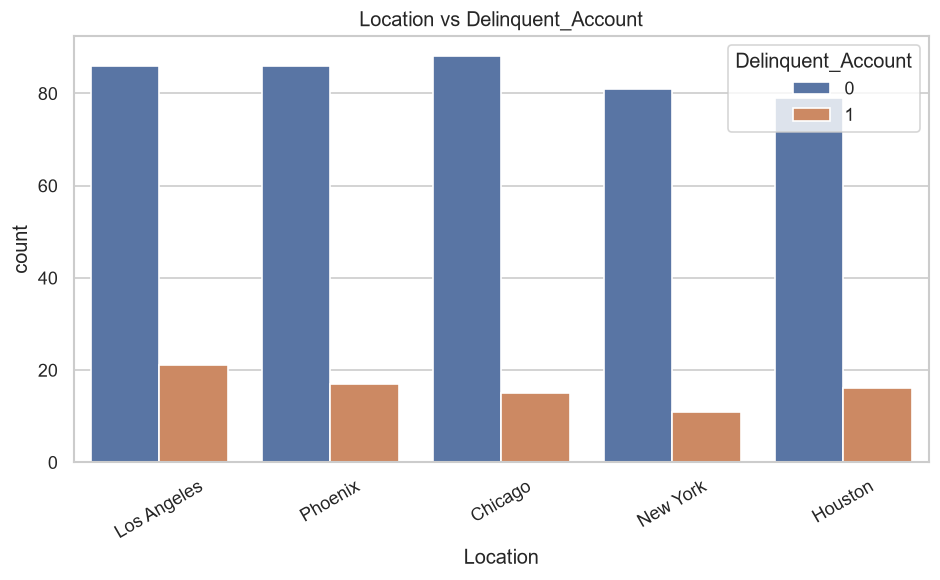

In [38]:
for feature in categorical_features:
    plot_categorical_vs_target(df, feature)

Correlation Analysis

Correlation Matrix

In [39]:
correlation = df.select_dtypes(include=np.number).corr()

correlation

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
Age,1.000000,0.006496,-0.034075,0.015811,-0.023511,0.022508,-0.051190,-0.007883,0.016942
Income,0.006496,1.000000,0.071287,0.041181,-0.004696,0.045409,-0.051285,-0.064181,-0.004901
Credit_Score,-0.034075,0.071287,1.000000,-0.021550,-0.014842,0.034833,-0.015618,-0.005362,-0.036904
Credit_Utilization,0.015811,0.041181,-0.021550,1.000000,0.019666,0.034224,-0.051119,-0.064661,0.065264
Missed_Payments,-0.023511,-0.004696,-0.014842,0.019666,1.000000,-0.026478,-0.015548,0.000148,-0.097345
Delinquent_Account,0.022508,0.045409,0.034833,0.034224,-0.026478,1.000000,-0.004320,0.034386,-0.039829
Loan_Balance,-0.051190,-0.051285,-0.015618,-0.051119,-0.015548,-0.004320,1.000000,0.056971,0.054607
Debt_to_Income_Ratio,-0.007883,-0.064181,-0.005362,-0.064661,0.000148,0.034386,0.056971,1.000000,0.026144
Account_Tenure,0.016942,-0.004901,-0.036904,0.065264,-0.097345,-0.039829,0.054607,0.026144,1.000000


Heatmap

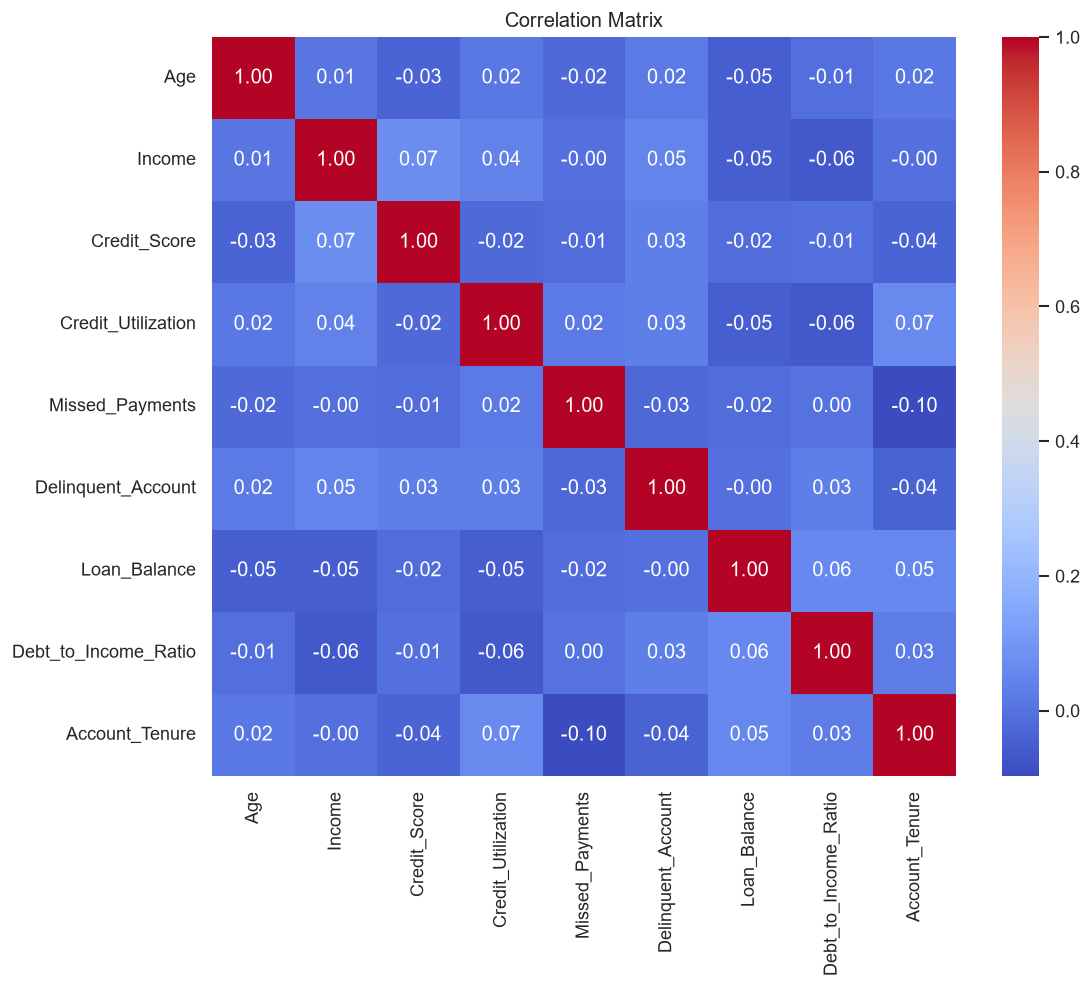

In [40]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Correlation with Target

In [41]:
correlation['Delinquent_Account']\
    .sort_values(ascending=False)

Delinquent_Account      1.000000
Income                  0.045409
Credit_Score            0.034833
Debt_to_Income_Ratio    0.034386
Credit_Utilization      0.034224
Age                     0.022508
Loan_Balance           -0.004320
Missed_Payments        -0.026478
Account_Tenure         -0.039829
Name: Delinquent_Account, dtype: float64

Monthly Payment Behaviour

In [42]:
payment_columns = [
    'Month_1',
    'Month_2',
    'Month_3',
    'Month_4',
    'Month_5',
    'Month_6'
]

df[payment_columns].head()

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,Late,Late,Missed,Late,Missed,Late
1,Missed,Missed,Late,Missed,On-time,On-time
2,Missed,Late,Late,On-time,Missed,Late
3,Late,Missed,Late,Missed,Late,Late
4,Missed,On-time,Missed,Late,Late,Late


In [43]:
for col in payment_columns:
    print(df[col].value_counts())

Month_1
On-time    177
Missed     164
Late       159
Name: count, dtype: int64
Month_2
Late       173
Missed     167
On-time    160
Name: count, dtype: int64
Month_3
Late       169
On-time    169
Missed     162
Name: count, dtype: int64
Month_4
Late       181
Missed     160
On-time    159
Name: count, dtype: int64
Month_5
Missed     187
On-time    162
Late       151
Name: count, dtype: int64
Month_6
Late       172
Missed     168
On-time    160
Name: count, dtype: int64


Grouped Statistics

In [44]:
df.groupby("Delinquent_Account")[
    numerical_features
].mean().T

Delinquent_Account,0,1
Age,46.107143,47.100000
Income,107306.943005,113902.013333
Credit_Score,575.145933,591.150000
Credit_Utilization,0.488505,0.506887
Missed_Payments,2.990476,2.850000
Loan_Balance,48708.756281,48358.232877
Debt_to_Income_Ratio,0.297445,0.306301
Account_Tenure,9.842857,9.200000


In [45]:
df.groupby("Delinquent_Account")[
    numerical_features
].median().T

Delinquent_Account,0,1
Age,46.000000,50.000000
Income,106730.000000,108468.000000
Credit_Score,582.000000,625.000000
Credit_Utilization,0.483751,0.493021
Missed_Payments,3.000000,3.000000
Loan_Balance,45024.500000,48942.000000
Debt_to_Income_Ratio,0.301634,0.303280
Account_Tenure,10.000000,9.000000


In [46]:
plt.savefig(
    "../visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 1200x720 with 0 Axes>

### Overall Relationship Analysis

The numerical variables exhibit very weak linear correlations with the target variable (Delinquent_Account). This suggests that customer delinquency in the current dataset is unlikely to be explained by any single numerical feature alone.

Future predictive models may benefit from feature engineering, interaction variables, or non-linear machine learning algorithms capable of capturing more complex relationships.

Age

Customers with delinquent accounts appear slightly older on average; however, the overlap between the two groups is substantial. Age alone is unlikely to be a strong predictor of delinquency.

Income

Although delinquent customers exhibit a marginally higher median income, the distributions overlap considerably. Income does not appear to independently explain delinquency within this dataset.

Credit Score

Credit scores show only a modest difference between delinquent and non-delinquent customers. This suggests that credit score alone may not sufficiently distinguish delinquency risk in the current sample.

Credit Utilization

Customers with delinquent accounts demonstrate slightly higher credit utilization, although the distributions largely overlap. Additional analysis combining utilization with other financial indicators may reveal stronger predictive patterns.

Loan Balance

Loan balances appear comparable across both customer groups, indicating that outstanding loan amount alone is not a meaningful discriminator of delinquency.

Debt-to-Income Ratio

Delinquent customers exhibit marginally higher debt-to-income ratios. While the difference is limited, this feature may become more informative when combined with other financial variables.

Account Tenure

Account tenure shows only minor differences between customer groups, suggesting that customer longevity alone is not strongly associated with delinquency.

# Categorical Variables

Employment Status

Customers categorized as unemployed appear to have a relatively higher number of delinquent accounts compared to other employment groups. This relationship warrants further investigation using proportional analysis rather than raw counts.

Credit Card Type

Business credit card holders appear to contribute a larger number of delinquent accounts. However, further analysis using delinquency rates rather than counts is required before drawing conclusions.

Location

Customer delinquency appears relatively consistent across locations. No location demonstrates a markedly different delinquency pattern based on the current visualization.

# 9. Executive Summary

This section consolidates the findings from the exploratory data analysis into key business insights and recommendations. The objective is to summarize the current state of the dataset, highlight important risk indicators, and identify areas that require further investigation before predictive modeling.

In [47]:
# =====================================================
# Executive Summary Metrics
# =====================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Features",
        "Missing Values",
        "Duplicate Records",
        "Average Income",
        "Average Credit Score",
        "Average Credit Utilization",
        "Average Debt-to-Income Ratio",
        "Delinquency Rate"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        f"${df['Income'].mean():,.0f}",
        round(df['Credit_Score'].mean(),2),
        f"{df['Credit_Utilization'].mean()*100:.1f}%",
        f"{df['Debt_to_Income_Ratio'].mean()*100:.1f}%",
        f"{df['Delinquent_Account'].mean()*100:.1f}%"
    ]
})

summary_metrics

,Metric,Value
0,Total Customers,500
1,Total Features,19
2,Missing Values,70
3,Duplicate Records,0
4,Average Income,"$108,380"
5,Average Credit Score,577.72
6,Average Credit Utilization,49.1%
7,Average Debt-to-Income Ratio,29.9%
8,Delinquency Rate,16.0%


# 10. Key Findings

## Data Quality

- The dataset contains **500 customer records** and **19 variables**.
- Missing values are limited to three numerical variables: Income (7.8%), Loan Balance (5.8%), and Credit Score (0.4%).
- No duplicate records were identified.
- Numerical variables fall within expected business ranges, although a few customers exceed 100% credit utilization, indicating possible over-limit borrowing.

---

## Customer Characteristics

- The customer base is broadly distributed across age groups, income levels, and employment categories.
- Financial indicators such as credit score, debt-to-income ratio, and loan balance display realistic distributions.
- The dataset represents a diverse customer population suitable for exploratory analysis.

---

## Delinquency Analysis

- Approximately **16%** of customers are classified as delinquent, indicating moderate class imbalance.
- Individual numerical variables exhibit weak linear relationships with delinquency.
- Delinquency is likely influenced by combinations of financial and behavioral factors rather than any single feature.

In [49]:
risk_indicators = pd.DataFrame({
    "Risk Indicator": [
        "Missed Payments",
        "Credit Utilization",
        "Debt-to-Income Ratio",
        "Credit Score",
        "Employment Status",
        "Monthly Payment History"
    ],
    "Why It Matters": [
        "Reflects historical repayment behavior.",
        "May indicate financial stress when consistently high.",
        "Higher debt burden reduces repayment capacity.",
        "Represents overall creditworthiness.",
        "Employment stability may affect repayment ability.",
        "Captures customer payment behavior over time."
    ]
})

risk_indicators

,Risk Indicator,Why It Matters
0,Missed Payments,Reflects historical repayment behavior.
1,Credit Utilization,May indicate financial stress when consistentl...
2,Debt-to-Income Ratio,Higher debt burden reduces repayment capacity.
3,Credit Score,Represents overall creditworthiness.
4,Employment Status,Employment stability may affect repayment abil...
5,Monthly Payment History,Captures customer payment behavior over time.


In [50]:
risk_indicators = pd.DataFrame({
    "Risk Indicator": [
        "Missed Payments",
        "Credit Utilization",
        "Debt-to-Income Ratio",
        "Credit Score",
        "Employment Status",
        "Monthly Payment History"
    ],
    "Why It Matters": [
        "Reflects historical repayment behavior.",
        "May indicate financial stress when consistently high.",
        "Higher debt burden reduces repayment capacity.",
        "Represents overall creditworthiness.",
        "Employment stability may affect repayment ability.",
        "Captures customer payment behavior over time."
    ]
})

risk_indicators

,Risk Indicator,Why It Matters
0,Missed Payments,Reflects historical repayment behavior.
1,Credit Utilization,May indicate financial stress when consistentl...
2,Debt-to-Income Ratio,Higher debt burden reduces repayment capacity.
3,Credit Score,Represents overall creditworthiness.
4,Employment Status,Employment stability may affect repayment abil...
5,Monthly Payment History,Captures customer payment behavior over time.


# 12. Next Steps

The cleaned dataset produced through this exploratory analysis is now ready for predictive modeling.

Future work may include:

- Feature engineering
- Data preprocessing
- Class imbalance treatment
- Model training and evaluation
- Model explainability using SHAP or feature importance
- Deployment of a delinquency prediction model